In [1]:
import jax 
from jax import numpy as jnp
from jax.numpy import linalg as jnpla
from jax.scipy import linalg as jspla
from jax import random as jrnd
from matplotlib import pyplot as plt

from spectral import *

In [8]:
x = jnp.array([1, 2, 3])
print(jnp.pad(x[None], ((0, 3), (0, 0))))

[[1 2 3]
 [0 0 0]
 [0 0 0]
 [0 0 0]]


In [32]:
import jax
from jax import lax
from jax import numpy as jnp
from jax import tree_util as jtu

### ORTHOGONAL POLYNOMIALS ###
# Nulls added for compatibility with Hermite scaling
# Chebyshev (first kind)
def state_T(x:jax.Array, null:float = 0) -> jax.Array:
    """First two terms of three-term recurrence for Chebyshev 
    polynomials of the first kind."""
    return x, jnp.ones_like(x), x, 0.

def ttr_T(state:tuple, i:int) -> tuple[tuple[jax.Array, jax.Array, jax.Array], jax.Array]:
    """lax.scan-formatted three-term recurrence for Chebyshev
    polynomials of the first kind."""
    x, T_im1, T_i, _ = state
    T_ip1 = 2 * x * T_i - T_im1
    return (x, T_i, T_ip1, 0.), T_ip1

# Chebyshev (second kind)
def state_U(x:jax.Array, null:float = 0.) -> jax.Array:
    """lax.scan-formatted three-term recurrence for Chebyshev
    polynomials of the second kind."""
    return x, jnp.ones_like(x), 2 * x, 0.

def ttr_U(state:tuple, i:int) -> tuple[tuple[jax.Array, jax.Array, jax.Array], jax.Array]:
    """lax.scan-formatted three-term recurrence for Chebyshev
    polynomials of the second kind."""
    x, U_im1, U_i, _ = state
    U_ip1 = 2 * x * U_i - U_im1
    return (x, U_i, U_ip1, 0.), U_ip1

# Legendre 
def state_P(x:jax.Array, null:float = 0.) -> jax.Array:
    """First two terms of the three-term recurrence for Legendre
    polynomials. """
    return x, jnp.ones_like(x), x, 0.

def ttr_P(state:tuple, i:int) -> tuple[tuple[jax.Array, jax.Array, jax.Array], jax.Array]:
    """lax.scan-formatted three-term recurrence for Legendre
    polynomials."""
    x, P_im1, P_i, _ = state
    P_ip1 = ((2 * i + 1) * x * P_i - i * P_im1) / (i + 1)
    return (x, P_i, P_ip1, 0.), P_ip1

# Hermite (no matrix TTR)
def state_H(x:jax.Array, alpha:float = 1) -> jax.Array:
    """First two terms of the three-term recurrence for generalized Hermite
    polynomials. """
    return x, jnp.ones_like(x), x / jnp.sqrt(alpha), alpha

def ttr_H(state:tuple, i:int) -> tuple[tuple[jax.Array, jax.Array, jax.Array], jax.Array]:
    """lax.scan-formatted three-term recurrence for generalized Hermite
    polynomials."""
    x, H_im1, H_i, alpha = state
    H_ip1 = x * H_i - i * alpha * H_im1
    return (x, H_i, H_ip1, alpha), H_ip1

# Scaling functions to [-1, 1]
def scale_ones(x):
    return 2 * (x - x.min(axis = 0)) / (x.max(axis = 0) - x.min(axis = 0)) - 1

# Dictionary for all bases
psi_dict = {'T': {'state': state_T,
                  'ttr': ttr_T,
                  'scale': scale_ones},
            'U': {'state': state_U,
                  'ttr': ttr_U,
                  'scale': scale_ones},
            'P': {'state': state_P,
                  'ttr': ttr_P,
                  'scale': scale_ones},
            'H': {'state': state_H,
                  'ttr': ttr_H,
                  'scale': lambda x: x}}

# Univariate orthogonal polynomial collection
# TODO: jit with staticargs basis, k_exc
def uv_psi(x:jax.Array, basis:str, k:int, alpha:float = 1.) -> jax.Array:
    """
    Generates a collection of univariate orthogonal polynomials evaluated at points x.

    Parameters
    ----------
    x : jax.Array
        Input points at which to evaluate the polynomials.
    basis : str
        Polynomial basis type. Must be one of 'T' (Chebyshev 1st kind), 
        'U' (Chebyshev 2nd kind), 'P' (Legendre), or 'H' (Hermite).
    k_exc : int
        Number of polynomial orders to generate (exclusive upper bound).
        The highest order generated will be k - 1.
    alpha : float = 1
        For the Hermite basis, alpha controls std. This is different than merely stretching the 
        polynomials. For all other polynomials, alpha does nothing.

    Returns
    -------
    jax.Array
        Array of shape (n, k_exc) containing the evaluated polynomials at x,
        from order 0 up to k_exc - 1.
    """
    # Scale x
    scale_fn = psi_dict[basis]['scale']
    x_scaled = scale_fn(x)

    # Polynomial generation and return
    init_state = psi_dict[basis]['state'](x_scaled, alpha)
    ttr = psi_dict[basis]['ttr']
    k_range = jnp.arange(1, k)
    _, y = lax.scan(ttr, init_state, k_range)
    y = jnp.concatenate([jnp.array(init_state[1:-1]), y])

    return y.T

# Multivariate Orthopoly
def mv_psi(X:jax.Array, basis:str, k_total:int, alpha:jax.Array) -> jax.Array:
    """
    Generates a collection of multivariate orthogonal polynomials evaluated at points X.

    Parameters
    ----------
    X : jax.Array
        Input points at which to evaluate the polynomials, shape (n, dim).
    basis : str
        Polynomial basis type. Must be one of 'T' (Chebyshev 1st kind), 
        'U' (Chebyshev 2nd kind), 'P' (Legendre), or 'H' (Hermite).
    k_total : int
        Maximum total polynomial order (sum of orders across dimensions).
    alpha : jax.Array
        For the Hermite basis, alpha controls std. This is different than merely stretching the 
        polynomials. Must of shape (dim,). 

    Returns
    -------
    jax.Array
        Array of shape (n, num_terms) containing the evaluated multivariate polynomials at X,
        where num_terms is the number of multi-indices with sum <= k_total.
    """

    n, dim = X.shape
    # Domain inference
    scale_fn = psi_dict[basis]['scale']
    X_scaled = scale_fn(X)

    alpha = jnp.atleast_1d(alpha)
    alpha = jnp.broadcast_to(alpha, (dim,))

    # Generate univariate polynomials for each dimension of shape (dim, n, k_total + 1)
    # Lambda fn for easy vmap
    uv_psi_partial = jtu.Partial(uv_psi, basis = basis, k_exc = k_total + 1)
    Y = jax.vmap(lambda X_scaled, alpha: uv_psi_partial(X_scaled, alpha = alpha), in_axes = (1, 0), out_axes = 1)(X_scaled, alpha)
    
    # Multiplication indices
    j = jnp.stack(jnp.meshgrid(*[jnp.arange(k_total)] * dim), axis = -1).reshape((k_total) ** dim, dim)
    j = j[j.sum(axis = 1) <= k_total]
    i = jnp.stack([jnp.arange(dim)] * j.shape[0])
    
    # Take product and return
    Y = jnp.prod(Y[:, i, j], axis = -1)

    return Y

# Matrix Orthopoly
# Only using Chebyshev First Kind
def state_T_mat(A:jax.Array, Omega:jax.Array, rho:float) -> jax.Array:
    """First two terms of three-term recurrence for Chebyshev matrix
    polynomials of the first kind."""
    return A, Omega, (A - rho) @ Omega / (2 * rho), rho

def ttr_T_mat(state:tuple, i:int) -> tuple[tuple[jax.Array, jax.Array, jax.Array], jax.Array]:
    """lax.scan-formatted three-term recurrence for Chebyshev matrix
    polynomials of the first kind."""
    A, T_im1, T_i, rho = state
    n = A.shape[0]
    T_ip1 = ((A / rho - jnp.eye(n)) @ T_i - T_im1 / 4)
    return (A, T_i, T_ip1, rho), T_ip1

# Scale spectrum to [-1, 1]
def scale_spec_rho(A:jax.Array, 
                        n_iters:int = 3, key:jax.Array = jrnd.key(0)):
    n = A.shape[0]

    b0 = jrnd.normal(key, (n,))
    def pow_iter(i, b):
        b = A @ b
        b = b / jnpla.norm(b)
        return b
    b = lax.fori_loop(0, n_iters, pow_iter, b0)
    lmda_max = b.T @ A @ b

    rho = lmda_max / 2
    return rho

# Block Krylov for Chebyshev Matrix Polynomials
def mat_psi(A:jax.Array, Omega:jax.Array, k:int) -> jax.Array:
    """
    Generates a collection of univariate orthogonal polynomials evaluated at points x.

    Parameters
    ----------
    A : jax.Array
        Input matrix (upon?... at?...) which to evaluate the polynomials
        of shape (n, n).
    Omega: jax.Array
        Initial matrix (instead of a constant) used to construct polynomials
        (first term is Omega instead of a constant matrix) of shape (n, d).
    basis : str
        Polynomial basis type. Must be one of 'T' (Chebyshev 1st kind), 
        'U' (Chebyshev 2nd kind), or 'P' (Legendre).
    k : int
        Number of polynomial orders to generate (exclusive upper bound).
        The highest order generated will be k - 1.

    Returns
    -------
    jax.Array
        Array of shape (n, n, k_exc) containing the evaluated polynomials at x,
        from order 0 up to k - 1.
    """

    # Get scaling constant for
    #   A
    rho = scale_spec_rho(A)

    # Polynomial generation and return
    init_state = state_T_mat(A, Omega, rho)
    ttr = ttr_T_mat
    k_range = jnp.arange(1, k)
    _, y = lax.scan(ttr, init_state, k_range)
    y = jnp.concatenate([jnp.array(init_state[1:2]), y])

    return y.transpose(1, 2, 0)

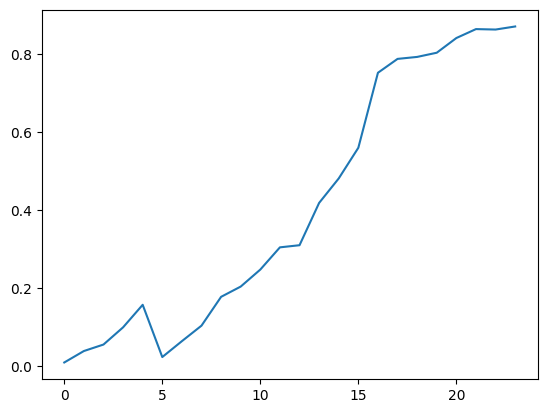

In [43]:
# d MUST BE DIVISIBLE BY b

def sRR(A:jax.Array, d:int, b:int, 
        tol_stab:float = 1e-8, tol_conv:float = 1e-8, 
        key:jax.Array = jrnd.key(0)):
    n,n = A.shape
    # Partition size (number of Chebpoly)
    k = d // b

    # Sketch matrix
    Omega = jrnd.normal(key, (n, b))
    Omega = Omega / jnpla.matrix_norm(Omega)
    # Polynomial basis with first entry omega
    C = mat_psi(A, Omega, k).reshape(n, -1, order = "F")

    Q,R = jnpla.qr(C)
    T = Q.T @ A @ Q
    eigvals, eigvecs = jnpla.eigh(T)
    eigvecs = Q @ eigvecs
    eigvals2 = jnp.sort(jnpla.eigvals(A))[::-1]
    plt.plot(jnp.abs(1 - eigvals[::-1] / eigvals2[:d]))
    #return eigvals, eigvecs

n = 90
A = jnp.diag(jrnd.randint(jrnd.key(0), (n,), minval = -10, maxval = 10))
A = A @ A.T
sRR(A, 24, 8)

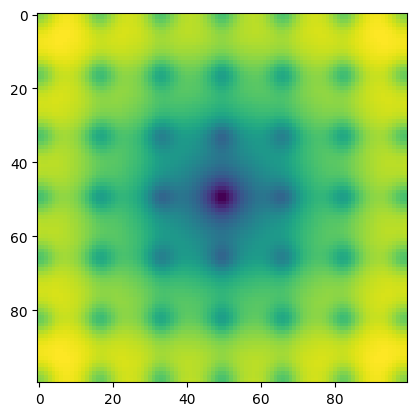

In [ ]:
def ackley(xy):
    a, b, c, d = 20, 0.5, 2 * jnp.pi, 1.3
    sum1 = -b * jnp.sqrt(jnp.sum(xy**2) / d)
    sum2 = jnp.sum(jnp.cos(c * xy)) / d
    return -a * jnp.exp(sum1) - jnp.exp(sum2) + a + jnp.exp(1)
ackley = jax.vmap(ackley)

xy = jnp.stack(jnp.meshgrid(*[jnp.linspace(-3, 3, 100)] * 2), axis = -1).reshape(100 ** 2, 2)

plt.imshow(ackley(xy).reshape(100, 100))